<a href="https://colab.research.google.com/github/Haidermushtaq/Computer-Vision-/blob/main/Lab05_HOG_Defect_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 05: HOG Based Industrial Defect Detection and Classification

**Pipeline:** Image → Preprocessing → HOG features → ML classifier → Defective / Non-Defective → Accept / Reject

**Before you run (Colab):**
1. Runtime → Run all. The dataset is downloaded with `kagglehub`, no API key needed.
2. The last cell downloads the finished Word report.

## 1. Setup and dataset download

In [1]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    get_ipython().system('pip -q install -U python-docx kagglehub')

import os, re, glob, random, time, warnings
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from skimage.feature import hog
from skimage import exposure
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from joblib import Parallel, delayed
import joblib

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED)
os.makedirs("figs", exist_ok=True)
RES = {}   # everything the report needs is stored here

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 5.4 MB/s eta 0:00:00


In [2]:
SLUG = "sovitrath/neu-steel-surface-defect-detect-trainvalid-split"
DATA_DIR = "neu_data"
IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp")

def find_images(root):
    return sorted(p for p in glob.glob(f"{root}/**/*", recursive=True) if p.lower().endswith(IMG_EXT))

if not find_images(DATA_DIR):
    # no API key used: clear any token left over from earlier runs, then download the public dataset
    os.environ.pop("KAGGLE_API_TOKEN", None)
    for f in ("~/.kaggle/access_token", "~/.kaggle/kaggle.json"):
        f = os.path.expanduser(f)
        if os.path.exists(f): os.remove(f)
    import kagglehub
    DATA_DIR = kagglehub.dataset_download(SLUG)
    print("Path to dataset files:", DATA_DIR)

print("Images found:", len(find_images(DATA_DIR)))

Using Colab cache for faster access to the 'neu-steel-surface-defect-detect-trainvalid-split' dataset.
Path to dataset files: /kaggle/input/neu-steel-surface-defect-detect-trainvalid-split
Images found: 1800


## 2. Load and inspect the dataset

Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
XML annotation files matched: 1800 of 1800


split,train,valid,All
label,,,
crazing,240,60,300
inclusion,240,60,300
patches,240,60,300
pitted_surface,240,60,300
rolled-in_scale,240,60,300
scratches,240,60,300
All,1440,360,1800


Example image shape: (200, 200) dtype: uint8


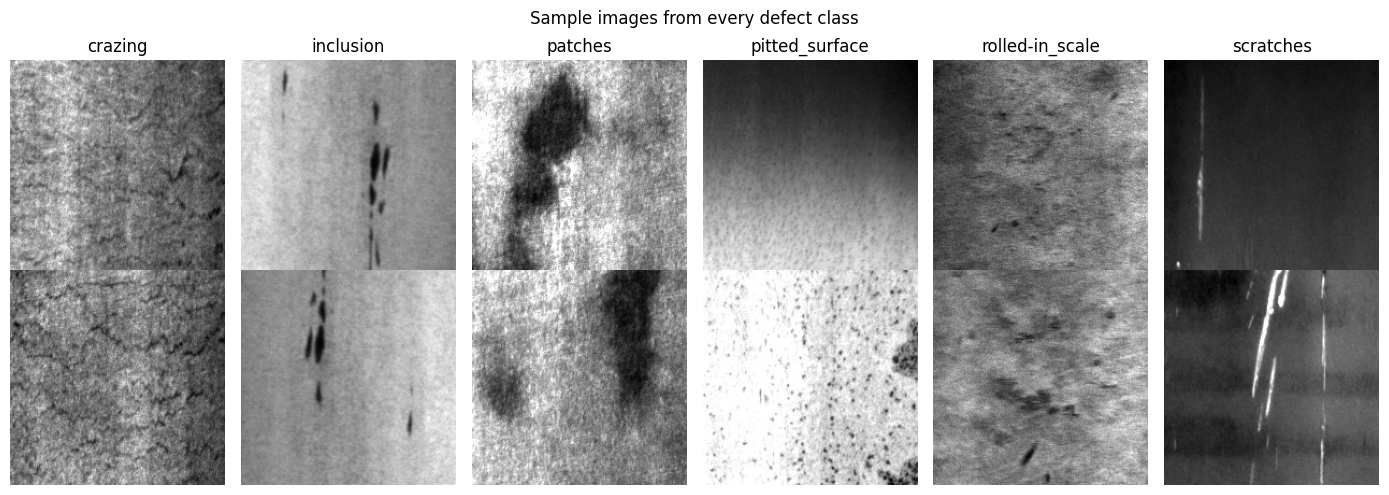

In [3]:
all_imgs = find_images(DATA_DIR)
xml_map = {os.path.splitext(os.path.basename(p))[0]: p
           for p in glob.glob(f"{DATA_DIR}/**/*.xml", recursive=True)}

def find_xml(p):
    stem = os.path.splitext(p)[0]
    cands = [stem + ".xml"]
    for a, b in (("images", "annotations"), ("images", "Annotations"), ("IMAGES", "ANNOTATIONS")):
        cands.append(stem.replace(f"/{a}/", f"/{b}/") + ".xml")
    for c in cands:
        if os.path.exists(c): return c
    return xml_map.get(os.path.basename(stem))

def label_of(p):
    m = re.match(r"(.+?)_\d+$", os.path.splitext(os.path.basename(p))[0].lower())
    return m.group(1) if m else None

def split_of(p):
    parts = [s.lower() for s in p.replace("\\", "/").split("/")]
    if any(s in ("train", "training") for s in parts): return "train"
    if any(s in ("valid", "val", "validation", "test") for s in parts): return "valid"
    return None

df = pd.DataFrame({"path": all_imgs})
df["label"] = df.path.map(label_of)
df["split"] = df.path.map(split_of)
df = df.dropna(subset=["label"]).reset_index(drop=True)

if df.split.isna().any():   # no train/valid folders, make our own stratified split
    tr, va = train_test_split(df.index, test_size=0.2, stratify=df.label, random_state=SEED)
    df.loc[tr, "split"] = "train"; df.loc[va, "split"] = "valid"

CLASSES = sorted(df.label.unique())
df["y"] = df.label.map({c: i for i, c in enumerate(CLASSES)})
df["has_xml"] = df.path.map(lambda p: find_xml(p) is not None)

print("Classes:", CLASSES)
print("XML annotation files matched:", int(df.has_xml.sum()), "of", len(df))
display(pd.crosstab(df.label, df.split, margins=True))

g0 = cv2.imread(df.path[0], cv2.IMREAD_GRAYSCALE)
print("Example image shape:", g0.shape, "dtype:", g0.dtype)

fig, ax = plt.subplots(2, 6, figsize=(14, 5))
for j, c in enumerate(CLASSES[:6]):
    for i, p in enumerate(df[df.label == c].path.head(2)):
        ax[i, j].imshow(cv2.imread(p, 0), cmap="gray"); ax[i, j].axis("off")
        if i == 0: ax[i, j].set_title(c)
plt.suptitle("Sample images from every defect class"); plt.tight_layout()
plt.savefig("figs/samples.png", dpi=130, bbox_inches="tight"); plt.show()
RES["class_counts"] = pd.crosstab(df.label, df.split)

## 3. Build the binary task (Normal vs Defective)

NEU-DET only contains defective surfaces, there are no clean product images in it. To still get a Normal class, I use the XML boxes:

- **Defective sample:** a 100×100 window centred on the defect box.
- **Normal sample:** a 100×100 window cut from the same image in a spot that does not overlap any defect box (up to two per image).

The split follows the dataset: `train` for training, `valid` for the final test. The multi class task (6 defect types) uses the full images.

Binary train: 3110  (normal 1670, defective 1440)
Binary test : 763  (normal 403, defective 360)


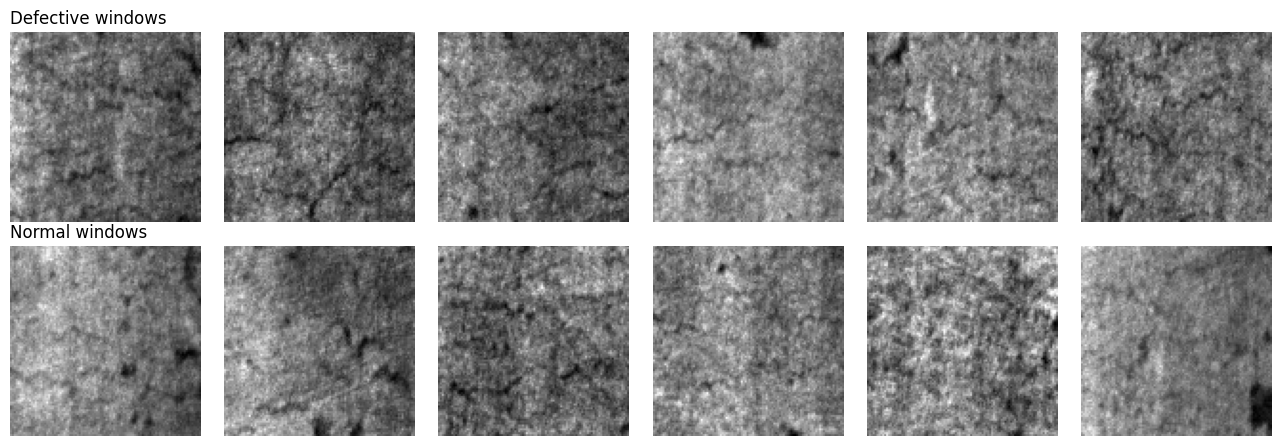

In [4]:
W = 100   # window size used for the binary task

def get_boxes(p):
    x = find_xml(p)
    if not x: return []
    out = []
    for o in ET.parse(x).getroot().iter("object"):
        b = o.find("bndbox")
        if b is not None:
            out.append(tuple(int(float(b.find(k).text)) for k in ("xmin", "ymin", "xmax", "ymax")))
    return out

def make_crops(path, rng):
    g = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    H, Wd = g.shape
    boxes = get_boxes(path)
    mask = np.zeros((H, Wd), np.uint8)
    for x1, y1, x2, y2 in boxes: mask[y1:y2, x1:x2] = 1
    if boxes:
        big = max(boxes, key=lambda b: (b[2]-b[0]) * (b[3]-b[1]))
        cx, cy = (big[0]+big[2])//2, (big[1]+big[3])//2
    else:
        cx, cy = Wd//2, H//2
    x0 = int(np.clip(cx - W//2, 0, Wd - W)); y0 = int(np.clip(cy - W//2, 0, H - W))
    defect = g[y0:y0+W, x0:x0+W]
    normals = []
    if boxes:
        for thr in (0.0, 0.05, 0.15, 0.30):      # relax only if a clean spot does not exist
            cands = [(x, y) for y in range(0, H-W+1, 10) for x in range(0, Wd-W+1, 10)
                     if mask[y:y+W, x:x+W].mean() <= thr]
            if cands:
                rng.shuffle(cands); picked = []
                for x, y in cands:
                    if all(abs(x-px) >= W//2 or abs(y-py) >= W//2 for px, py in picked):
                        picked.append((x, y))
                    if len(picked) == 2: break
                normals = [g[y:y+W, x:x+W] for x, y in picked]
                break
    return defect, normals

def build_binary(sub):
    rng = random.Random(SEED); X, y, grp = [], [], []
    for gi, p in enumerate(sub.path):
        d, ns = make_crops(p, rng)
        X.append(d); y.append(1); grp.append(gi)
        for n in ns: X.append(n); y.append(0); grp.append(gi)
    return np.array(X), np.array(y), np.array(grp)

tr_df = df[df.split == "train"].reset_index(drop=True)
te_df = df[df.split == "valid"].reset_index(drop=True)
Xb_tr, yb_tr, gb_tr = build_binary(tr_df)
Xb_te, yb_te, gb_te = build_binary(te_df)
assert (yb_tr == 0).sum() > 20, "Too few normal windows. Check that the XML annotation files were downloaded."

# multi class set (full images)
Xm_tr = np.array([cv2.imread(p, 0) for p in tr_df.path]); ym_tr = tr_df.y.values
Xm_te = np.array([cv2.imread(p, 0) for p in te_df.path]); ym_te = te_df.y.values

print(f"Binary train: {len(yb_tr)}  (normal {(yb_tr==0).sum()}, defective {(yb_tr==1).sum()})")
print(f"Binary test : {len(yb_te)}  (normal {(yb_te==0).sum()}, defective {(yb_te==1).sum()})")
RES["bin_counts"] = dict(tr_n=int((yb_tr==0).sum()), tr_d=int((yb_tr==1).sum()),
                         te_n=int((yb_te==0).sum()), te_d=int((yb_te==1).sum()))
RES["img_counts"] = dict(train=len(tr_df), valid=len(te_df), classes=len(CLASSES), shape=g0.shape)

fig, ax = plt.subplots(2, 6, figsize=(13, 4.5))
for i in range(6):
    ax[0, i].imshow(Xb_tr[yb_tr==1][i*7], cmap="gray"); ax[0, i].axis("off")
    ax[1, i].imshow(Xb_tr[yb_tr==0][i*7], cmap="gray"); ax[1, i].axis("off")
ax[0, 0].set_title("Defective windows", loc="left"); ax[1, 0].set_title("Normal windows", loc="left")
plt.tight_layout(); plt.savefig("figs/binary_samples.png", dpi=130, bbox_inches="tight"); plt.show()

## 4. Preprocessing and HOG feature extraction

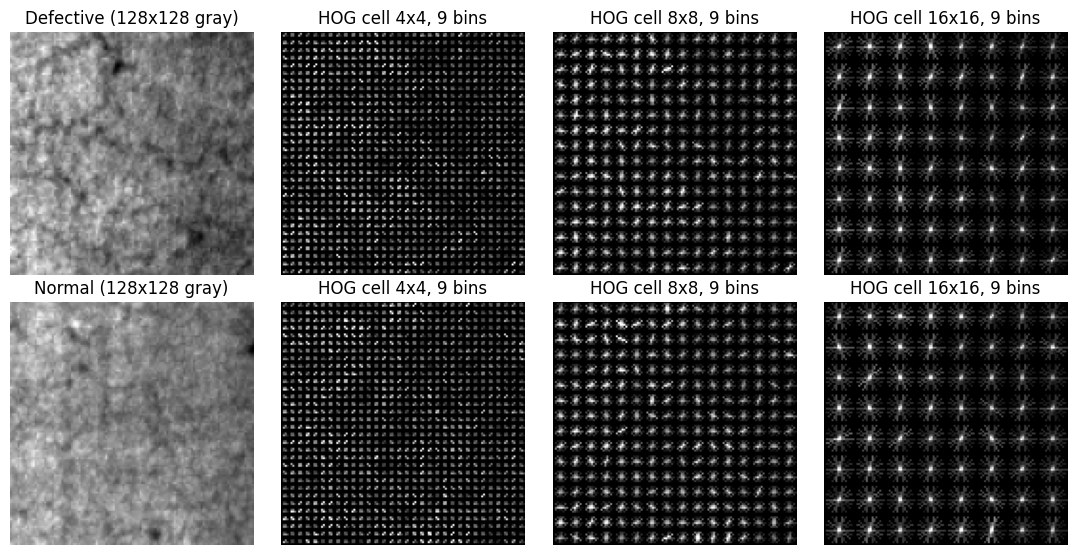

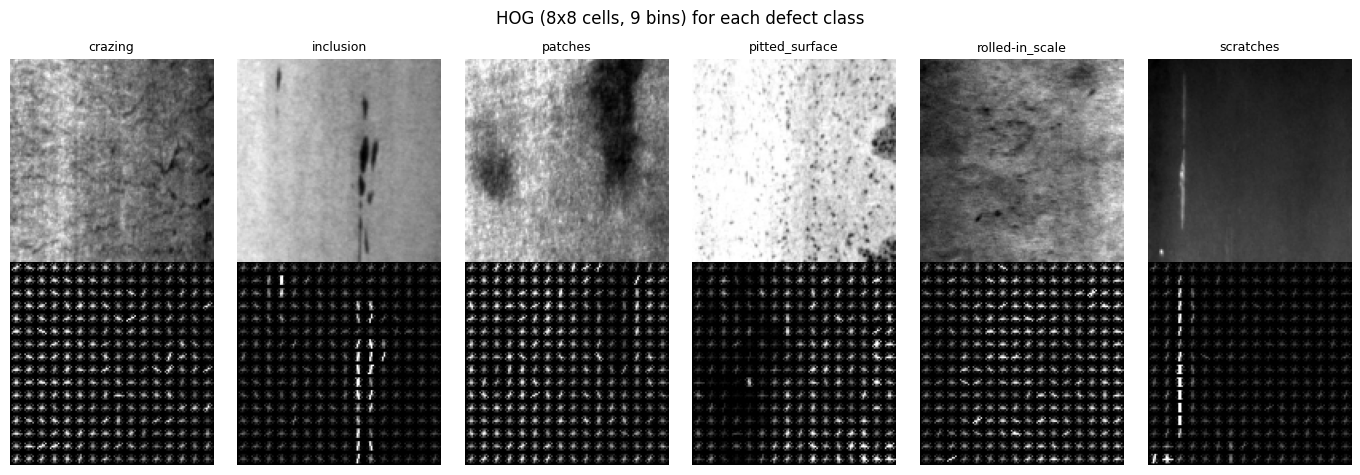

In [5]:
IMG_SIZE = 128

def preprocess(img):
    """grayscale + resize to a common resolution"""
    if img.ndim == 3: img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

def hog_one(img, cell, ori):
    return hog(img, orientations=ori, pixels_per_cell=(cell, cell), cells_per_block=(2, 2),
               block_norm="L2-Hys", feature_vector=True).astype(np.float32)

def hog_batch(imgs, cell, ori):
    imgs = [preprocess(i) for i in imgs]
    if len(imgs) < 64:
        return np.array([hog_one(i, cell, ori) for i in imgs])
    return np.array(Parallel(n_jobs=-1)(delayed(hog_one)(i, cell, ori) for i in imgs))

# HOG visualisation
def hog_vis(img, cell, ori=9):
    _, im = hog(preprocess(img), orientations=ori, pixels_per_cell=(cell, cell), cells_per_block=(2, 2),
                block_norm="L2-Hys", visualize=True)
    return exposure.rescale_intensity(im, in_range=(0, np.percentile(im, 99.5) + 1e-9))

fig, ax = plt.subplots(2, 4, figsize=(11, 5.6))
for r, (name, im) in enumerate([("Defective", Xb_tr[yb_tr==1][3]), ("Normal", Xb_tr[yb_tr==0][3])]):
    ax[r, 0].imshow(preprocess(im), cmap="gray"); ax[r, 0].set_title(f"{name} (128x128 gray)")
    for k, c in enumerate((4, 8, 16)):
        ax[r, k+1].imshow(hog_vis(im, c), cmap="gray"); ax[r, k+1].set_title(f"HOG cell {c}x{c}, 9 bins")
    for a in ax[r]: a.axis("off")
plt.tight_layout(); plt.savefig("figs/hog_vis.png", dpi=140, bbox_inches="tight"); plt.show()

# one HOG per defect class, full images
fig, ax = plt.subplots(2, len(CLASSES), figsize=(2.3*len(CLASSES), 4.8))
for j, c in enumerate(CLASSES):
    im = Xm_tr[ym_tr == j][0]
    ax[0, j].imshow(preprocess(im), cmap="gray"); ax[0, j].set_title(c, fontsize=9)
    ax[1, j].imshow(hog_vis(im, 8), cmap="gray")
    ax[0, j].axis("off"); ax[1, j].axis("off")
plt.suptitle("HOG (8x8 cells, 9 bins) for each defect class"); plt.tight_layout()
plt.savefig("figs/hog_classes.png", dpi=130, bbox_inches="tight"); plt.show()

## 5. Classifiers and metric helpers
Two classifiers: **SVM (RBF)** and **Random Forest**. Class weights are balanced because there are more defective windows than normal ones.

In [6]:
MODELS = {
    "SVM (RBF)":     lambda: SVC(C=10, kernel="rbf", gamma="scale", class_weight="balanced"),
    "Random Forest": lambda: RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                                    class_weight="balanced", random_state=SEED),
}

def metrics(y, p, avg="binary"):
    return dict(Accuracy=accuracy_score(y, p),
                Precision=precision_score(y, p, average=avg, zero_division=0),
                Recall=recall_score(y, p, average=avg, zero_division=0),
                F1=f1_score(y, p, average=avg, zero_division=0))

## 6. HOG parameter experiments (cell size × orientations)
Parameters are chosen on a validation split taken **from the training set** (grouped by source image so no image leaks across the split). The test set is not touched here.

cell  4 ori  6 done  (373s)
cell  4 ori  9 done  (847s)
cell  4 ori 12 done  (1443s)
cell  8 ori  6 done  (1551s)
cell  8 ori  9 done  (1686s)
cell  8 ori 12 done  (1862s)
cell 16 ori  6 done  (1896s)
cell 16 ori  9 done  (1942s)
cell 16 ori 12 done  (1993s)


Accuracy                      F1          
Model                 Random Forest SVM (RBF) Random Forest SVM (RBF)
Cell  Orient Features                                                
4x4   6      23064           0.7163    0.7544        0.6066    0.7166
      9      34596           0.6878    0.7417        0.5429    0.6907
      12     46128           0.6498    0.7179        0.5121    0.6704
8x8   6      5400            0.7544    0.7480        0.6869    0.7145
      9      8100            0.7163    0.7480        0.6294    0.7104
      12     10800           0.7100    0.7417        0.6501    0.7063
16x16 6      1176            0.7702    0.7242        0.7320    0.6969
      9      1764            0.7670    0.7338        0.7293    0.7053
      12     2352            0.7607    0.7338        0.7279    0.7083

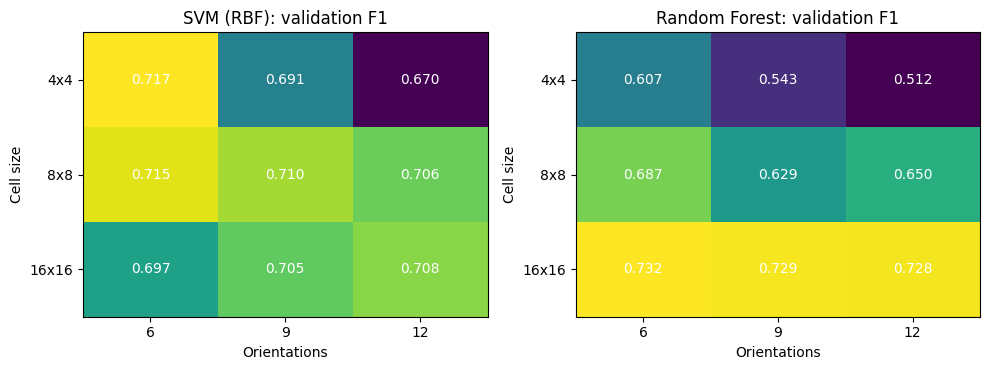


Best HOG setting (by SVM validation F1): cell 4x4, 6 orientations


In [7]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
tr_i, va_i = next(gss.split(Xb_tr, yb_tr, groups=gb_tr))

rows = []
t0 = time.time()
for cell in (4, 8, 16):
    for ori in (6, 9, 12):
        F_tr = hog_batch(Xb_tr[tr_i], cell, ori); F_va = hog_batch(Xb_tr[va_i], cell, ori)
        for name, mk in MODELS.items():
            m = mk().fit(F_tr, yb_tr[tr_i]); mt = metrics(yb_tr[va_i], m.predict(F_va))
            rows.append(dict(Cell=f"{cell}x{cell}", Orient=ori, Features=F_tr.shape[1], Model=name,
                             Accuracy=mt["Accuracy"], F1=mt["F1"]))
        print(f"cell {cell:2d} ori {ori:2d} done  ({time.time()-t0:.0f}s)")

sweep = pd.DataFrame(rows)
wide = sweep.pivot_table(index=["Cell", "Orient", "Features"], columns="Model", values=["Accuracy", "F1"]).round(4)
wide = wide.reindex(index=sorted(wide.index, key=lambda t: (int(t[0].split("x")[0]), t[1])))
display(wide)
RES["sweep"] = sweep

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
for a, name in zip(ax, MODELS):
    s = sweep[sweep.Model == name].pivot(index="Cell", columns="Orient", values="F1")
    s = s.reindex(["4x4", "8x8", "16x16"])
    im = a.imshow(s.values, cmap="viridis", aspect="auto")
    a.set_xticks(range(3)); a.set_xticklabels(s.columns); a.set_yticks(range(3)); a.set_yticklabels(s.index)
    a.set_xlabel("Orientations"); a.set_ylabel("Cell size"); a.set_title(f"{name}: validation F1")
    for i in range(3):
        for j in range(3): a.text(j, i, f"{s.values[i, j]:.3f}", ha="center", va="center", color="w")
plt.tight_layout(); plt.savefig("figs/sweep_heatmap.png", dpi=140, bbox_inches="tight"); plt.show()

best = sweep[sweep.Model == "SVM (RBF)"].sort_values(["F1", "Accuracy"], ascending=False).iloc[0]
BEST_CELL = int(best.Cell.split("x")[0]); BEST_ORI = int(best.Orient)
print(f"\nBest HOG setting (by SVM validation F1): cell {BEST_CELL}x{BEST_CELL}, {BEST_ORI} orientations")
RES.update(best_cell=BEST_CELL, best_ori=BEST_ORI)

## 7. Final training and test results (binary)

Feature vector length: 23064


,Accuracy,Precision,Recall,F1
Model,,,,
SVM (RBF),0.7680,0.7961,0.6833,0.7354
Random Forest,0.7077,0.8309,0.4778,0.6067


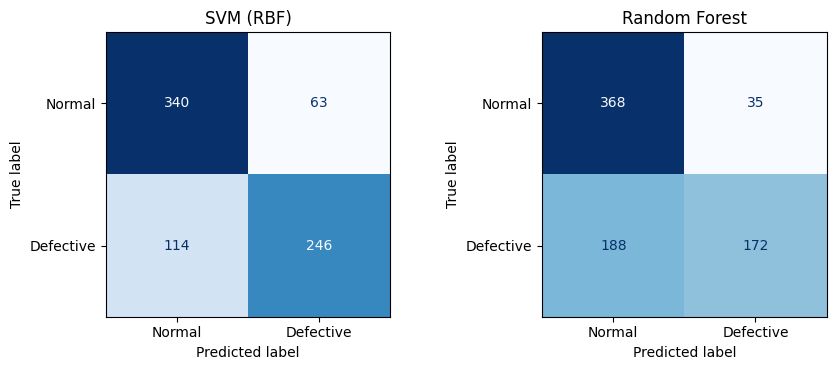


===== SVM (RBF) =====
              precision    recall  f1-score   support

      Normal      0.749     0.844     0.793       403
   Defective      0.796     0.683     0.735       360

    accuracy                          0.768       763
   macro avg      0.773     0.764     0.764       763
weighted avg      0.771     0.768     0.766       763


===== Random Forest =====
              precision    recall  f1-score   support

      Normal      0.662     0.913     0.767       403
   Defective      0.831     0.478     0.607       360

    accuracy                          0.708       763
   macro avg      0.746     0.695     0.687       763
weighted avg      0.742     0.708     0.692       763



In [8]:
F_tr = hog_batch(Xb_tr, BEST_CELL, BEST_ORI); F_te = hog_batch(Xb_te, BEST_CELL, BEST_ORI)
print("Feature vector length:", F_tr.shape[1])
RES["feat_len"] = F_tr.shape[1]

final = {}
for name, mk in MODELS.items():
    m = mk()
    if name.startswith("SVM"): m.set_params(probability=True, random_state=SEED)   # for confidence
    final[name] = m.fit(F_tr, yb_tr)
svm_final = final["SVM (RBF)"]

res_rows, preds = [], {}
for name, m in final.items():
    preds[name] = m.predict(F_te)
    res_rows.append(dict(Model=name, **metrics(yb_te, preds[name])))
final_tbl = pd.DataFrame(res_rows).set_index("Model").round(4)
display(final_tbl)
RES["final_tbl"] = final_tbl

fig, ax = plt.subplots(1, 2, figsize=(9, 3.8))
for a, name in zip(ax, final):
    ConfusionMatrixDisplay(confusion_matrix(yb_te, preds[name]),
                           display_labels=["Normal", "Defective"]).plot(ax=a, colorbar=False, cmap="Blues")
    a.set_title(name)
plt.tight_layout(); plt.savefig("figs/confusion.png", dpi=140, bbox_inches="tight"); plt.show()

for name in final:
    print(f"\n===== {name} =====")
    print(classification_report(yb_te, preds[name], target_names=["Normal", "Defective"], digits=3))
RES["cm"] = {n: confusion_matrix(yb_te, preds[n]) for n in final}

## 8. Advanced: 6 class defect type classification (full images)

,Accuracy,Precision,Recall,F1
Model,,,,
SVM (RBF),0.8167,0.8158,0.8167,0.8130
Random Forest,0.6056,0.6000,0.6056,0.5755


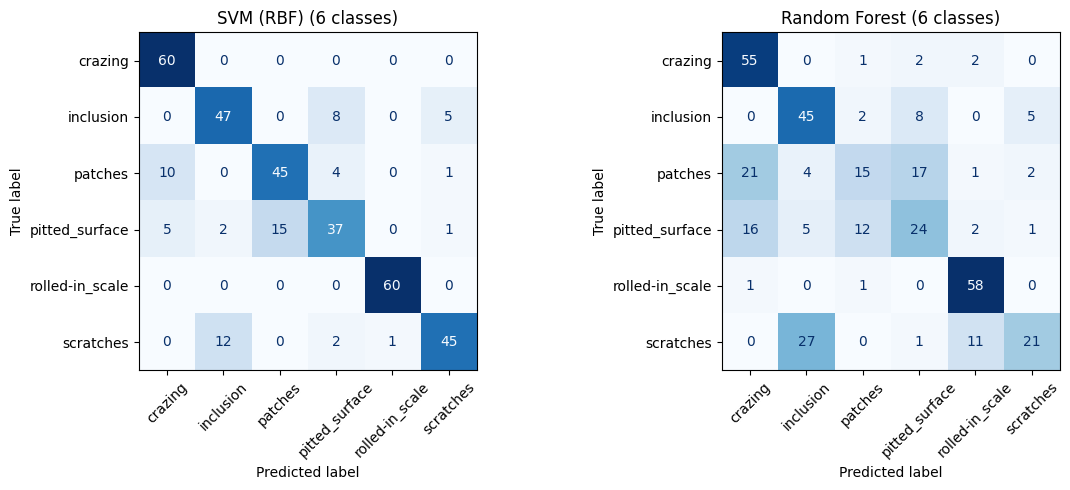

                 precision    recall  f1-score   support

        crazing      0.800     1.000     0.889        60
      inclusion      0.770     0.783     0.777        60
        patches      0.750     0.750     0.750        60
 pitted_surface      0.725     0.617     0.667        60
rolled-in_scale      0.984     1.000     0.992        60
      scratches      0.865     0.750     0.804        60

       accuracy                          0.817       360
      macro avg      0.816     0.817     0.813       360
   weighted avg      0.816     0.817     0.813       360



In [9]:
Fm_tr = hog_batch(Xm_tr, BEST_CELL, BEST_ORI); Fm_te = hog_batch(Xm_te, BEST_CELL, BEST_ORI)
multi, mrows, mpred = {}, [], {}
for name, mk in MODELS.items():
    multi[name] = mk().fit(Fm_tr, ym_tr); mpred[name] = multi[name].predict(Fm_te)
    mrows.append(dict(Model=name, **metrics(ym_te, mpred[name], "macro")))
multi_tbl = pd.DataFrame(mrows).set_index("Model").round(4)
display(multi_tbl)
RES["multi_tbl"] = multi_tbl
svm_multi = multi["SVM (RBF)"]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for a, name in zip(ax, multi):
    ConfusionMatrixDisplay(confusion_matrix(ym_te, mpred[name]), display_labels=CLASSES).plot(
        ax=a, colorbar=False, cmap="Blues", xticks_rotation=45)
    a.set_title(name + " (6 classes)")
plt.tight_layout(); plt.savefig("figs/confusion_multi.png", dpi=130, bbox_inches="tight"); plt.show()
print(classification_report(ym_te, mpred["SVM (RBF)"], target_names=CLASSES, digits=3))

## 9. Robustness experiment

In [ ]:
rng_np = np.random.default_rng(SEED)
def brightness(a, b=0): return lambda im: cv2.convertScaleAbs(im, alpha=a, beta=b)
def noise(s):
    return lambda im: np.clip(im.astype(np.float32) + rng_np.normal(0, s, im.shape), 0, 255).astype(np.uint8)
def rotate(deg):
    def f(im):
        h, w = im.shape
        M = cv2.getRotationMatrix2D((w/2, h/2), deg, 1.0)
        return cv2.warpAffine(im, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    return f
def blur(s): return lambda im: cv2.GaussianBlur(im, (0, 0), s)

CONDS = {
    "Clean (baseline)": lambda im: im,
    "Brightness darker (x0.6)": brightness(0.6),
    "Brightness brighter (x1.4)": brightness(1.4),
    "Brightness shift (+40)": brightness(1.0, 40),
    "Gaussian noise (sigma 10)": noise(10),
    "Gaussian noise (sigma 25)": noise(25),
    "Rotation 10 deg": rotate(10),
    "Rotation 30 deg": rotate(30),
    "Blur (sigma 1)": blur(1),
    "Blur (sigma 2)": blur(2),
}
rob = []
for name, fn in CONDS.items():
    Xp = np.array([fn(im) for im in Xb_te])
    p = svm_final.predict(hog_batch(Xp, BEST_CELL, BEST_ORI))
    mt = metrics(yb_te, p); rob.append(dict(Condition=name, Accuracy=mt["Accuracy"], F1=mt["F1"]))
rob = pd.DataFrame(rob)
rob["dAcc"] = rob.Accuracy - rob.Accuracy[0]; rob["dF1"] = rob.F1 - rob.F1[0]
rob = rob.round(4); display(rob)
RES["rob"] = rob

fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(rob)); ax.bar(x-0.2, rob.Accuracy, 0.4, label="Accuracy"); ax.bar(x+0.2, rob.F1, 0.4, label="F1")
ax.set_xticks(x); ax.set_xticklabels(rob.Condition, rotation=40, ha="right", fontsize=8)
ax.set_ylim(max(0, min(rob.F1.min(), rob.Accuracy.min()) - 0.1), 1.0); ax.legend(); ax.set_title("HOG + SVM under imaging changes")
plt.tight_layout(); plt.savefig("figs/robustness.png", dpi=140, bbox_inches="tight"); plt.show()

## 10. Industrial quality control decision module
A full product image is scanned with 100×100 windows (stride 50). If any window looks defective with probability above the threshold, the product is rejected. Small images are checked as a single window.

In [ ]:
REJECT_THRESHOLD = 0.5   # lower it (for example 0.3) if missing a defect costs more than a false reject
P1 = list(svm_final.classes_).index(1)

def inspect_product(image, thresh=REJECT_THRESHOLD, verbose=True):
    g = cv2.imread(image, cv2.IMREAD_GRAYSCALE) if isinstance(image, str) else image
    if g.ndim == 3: g = cv2.cvtColor(g, cv2.COLOR_BGR2GRAY)
    H, Wd = g.shape
    if min(H, Wd) <= int(W * 1.2):
        wins = [cv2.resize(g, (W, W), interpolation=cv2.INTER_AREA)]
    else:
        ys = sorted(set(list(range(0, H-W+1, 50)) + [H-W])); xs = sorted(set(list(range(0, Wd-W+1, 50)) + [Wd-W]))
        wins = [g[y:y+W, x:x+W] for y in ys for x in xs]
    pmax = float(svm_final.predict_proba(hog_batch(wins, BEST_CELL, BEST_ORI))[:, P1].max())
    defective = pmax >= thresh
    conf = pmax if defective else 1 - pmax
    dtype = None
    if defective and min(H, Wd) > int(W * 1.2):
        dtype = CLASSES[int(svm_multi.predict(hog_batch([g], BEST_CELL, BEST_ORI))[0])]
    if verbose:
        print("PRODUCT INSPECTION RESULT")
        print("Prediction:", "DEFECTIVE" if defective else "NON-DEFECTIVE")
        print(f"Confidence: {conf*100:.0f}%")
        print("Action:", "REJECT PRODUCT" if defective else "ACCEPT PRODUCT")
        if dtype: print("Likely defect type:", dtype)
        print()
    return dict(defective=defective, confidence=conf, p_defect=pmax, defect_type=dtype)

# demo on test images: some full defective products and some clean windows
demo_full = te_df.sample(3, random_state=1).path.tolist()
demo_norm = [Xb_te[yb_te == 0][i] for i in (0, 10)]
fig, ax = plt.subplots(1, 5, figsize=(14, 3.2))
for a, item in zip(ax, demo_full + demo_norm):
    r = inspect_product(item)
    img = cv2.imread(item, 0) if isinstance(item, str) else item
    a.imshow(img, cmap="gray"); a.axis("off")
    a.set_title(("REJECT" if r["defective"] else "ACCEPT") + f" ({r['confidence']*100:.0f}%)",
                color="red" if r["defective"] else "green")
plt.tight_layout(); plt.savefig("figs/qc_demo.png", dpi=130, bbox_inches="tight"); plt.show()

# sanity check on every defective product image in the test folder
t0 = time.time()
out = [inspect_product(p, verbose=False) for p in te_df.path]
RES["img_reject_rate"] = float(np.mean([o["defective"] for o in out]))
RES["sec_per_image"] = (time.time() - t0) / len(out)
print(f"Full test images rejected: {RES['img_reject_rate']*100:.1f}% (all of them are defective products)")
print(f"Time per full product image: {RES['sec_per_image']*1000:.0f} ms")

# threshold trade-off on the window level test set
pw = svm_final.predict_proba(F_te)[:, P1]
trade = []
for t in (0.2, 0.3, 0.4, 0.5, 0.6, 0.7):
    p = (pw >= t).astype(int)
    trade.append(dict(Threshold=t, Recall_defect=recall_score(yb_te, p), Precision_defect=precision_score(yb_te, p, zero_division=0),
                      False_accepts=int(((p == 0) & (yb_te == 1)).sum()), False_rejects=int(((p == 1) & (yb_te == 0)).sum())))
trade = pd.DataFrame(trade).round(3); display(trade); RES["trade"] = trade

## 11. Bonus: real time prototype (PASS / DEFECTIVE)
The cell below saves the model and a ready to run webcam script (`realtime_demo.py`). Run that script on a laptop with a camera, because Colab has no webcam. Inside Colab I simulate a video stream from test images so you can see the frame rate and the overlay.

In [ ]:
joblib.dump(dict(model=svm_final, cell=BEST_CELL, ori=BEST_ORI, W=W, img_size=IMG_SIZE), "hog_defect_model.joblib")

SCRIPT = r"""
# Real time HOG defect detector. Usage: python realtime_demo.py   (press q to quit)
import cv2, joblib, time
from skimage.feature import hog

M = joblib.load("hog_defect_model.joblib")
model, cell, ori, W, S = M["model"], M["cell"], M["ori"], M["W"], M["img_size"]
P1 = list(model.classes_).index(1)
cap = cv2.VideoCapture(0)
t_prev = time.time()
while True:
    ok, frame = cap.read()
    if not ok: break
    h, w = frame.shape[:2]; s = min(h, w) // 2; x0, y0 = (w - s) // 2, (h - s) // 2
    roi = cv2.cvtColor(frame[y0:y0+s, x0:x0+s], cv2.COLOR_BGR2GRAY)
    roi = cv2.resize(roi, (W, W), interpolation=cv2.INTER_AREA)
    g = cv2.resize(roi, (S, S), interpolation=cv2.INTER_AREA)
    feat = hog(g, orientations=ori, pixels_per_cell=(cell, cell), cells_per_block=(2, 2), block_norm="L2-Hys").reshape(1, -1)
    p = model.predict_proba(feat)[0, P1]
    bad = p >= 0.5
    color = (0, 0, 255) if bad else (0, 200, 0)
    cv2.rectangle(frame, (x0, y0), (x0+s, y0+s), color, 3)
    fps = 1 / (time.time() - t_prev); t_prev = time.time()
    cv2.putText(frame, ("DEFECTIVE" if bad else "PASS") + f"  {max(p, 1-p)*100:.0f}%  {fps:.0f} FPS", (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
    cv2.imshow("HOG inspection", frame)
    if cv2.waitKey(1) & 0xFF == ord("q"): break
cap.release(); cv2.destroyAllWindows()
"""
open("realtime_demo.py", "w").write(SCRIPT)

# simulated stream: each frame is a 480x640 canvas with a 100x100 sample in the middle (in the webcam script the user holds the part so it fills the centre box)
rng = random.Random(7)
idx = [rng.randrange(len(Xb_te)) for _ in range(60)]
frames, correct, t0 = [], 0, time.time()
for i in idx:
    canvas = np.full((480, 640, 3), 90, np.uint8)
    canvas[190:290, 270:370] = cv2.cvtColor(Xb_te[i], cv2.COLOR_GRAY2BGR)
    roi = cv2.cvtColor(canvas[190:290, 270:370], cv2.COLOR_BGR2GRAY)
    p = svm_final.predict_proba(hog_batch([roi], BEST_CELL, BEST_ORI))[0, P1]
    bad = p >= REJECT_THRESHOLD; correct += int(bad == bool(yb_te[i]))
    col = (0, 0, 255) if bad else (0, 200, 0)
    cv2.rectangle(canvas, (265, 185), (375, 295), col, 3)
    cv2.putText(canvas, ("DEFECTIVE" if bad else "PASS") + f"  {max(p, 1-p)*100:.0f}%", (20, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 1.1, col, 2)
    frames.append(canvas)
fps = len(idx) / (time.time() - t0)
print(f"Simulated stream: {fps:.1f} frames/s, {correct}/{len(idx)} frames labelled correctly")
RES["fps"] = fps

try:
    vw = cv2.VideoWriter("inspection_stream_demo.mp4", cv2.VideoWriter_fourcc(*"mp4v"), 10, (640, 480))
    for f in frames: vw.write(f)
    vw.release()
except Exception as e:
    print("Video file not written:", e)

fig, ax = plt.subplots(1, 4, figsize=(14, 3.4))
for a, f in zip(ax, frames[:4]):
    a.imshow(cv2.cvtColor(f, cv2.COLOR_BGR2RGB)); a.axis("off")
plt.tight_layout(); plt.savefig("figs/stream_demo.png", dpi=120, bbox_inches="tight"); plt.show()